In [78]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# Load and filter data
df = pd.read_csv('house_prices.csv')
df.fillna({'price': 0, 'bedrooms': 0, 'sqft_living': 0, 'sqft_lot': 0, 'sqft_above': 0, 'bathrooms': 0}, inplace=True)
mask = df['bedrooms'].isin([3, 4, 5])
filtered_df = df[mask]

In [79]:
# Features and target
X = filtered_df[['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']] #Features
y = filtered_df['price'] #target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [80]:
# Train model
model = LinearRegression() #Multi Feature Predictions Model
model.fit(X_train, y_train)
print(f"Model R² Score: {model.score(X_test, y_test):.2f}")

Model R² Score: 0.24


In [81]:
# Predict and evaluate
y_pred = model.predict(X_test)
print(f"First 5 predictions: {y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
errors = y_test.values - y_pred
print(f"First 5 prediction errors: {errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(errors)):.1f}")


First 5 predictions: [635030.92273903 261967.643622   793917.48659734 688975.31150258
 405084.16518146]
First 5 actual prices: [522500.  148612.5 409124.  800000.  275000. ]
First 5 prediction errors: [-112530.92273903 -113355.143622   -384793.48659734  111024.68849742
 -130084.16518146]
Mean Absolute Error: 207827.2


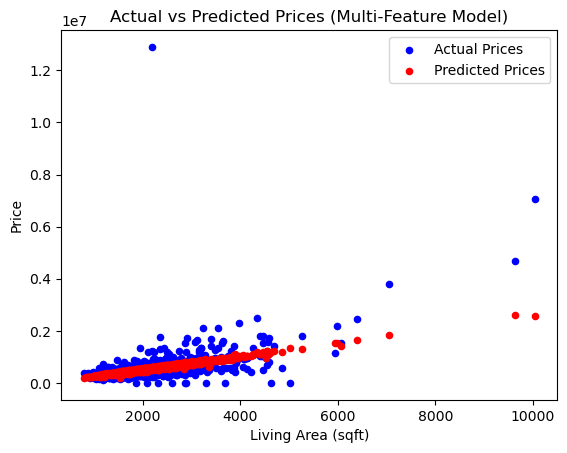

In [82]:
# Visualize predictions (using sqft_living for x-axis)
plot_df = pd.DataFrame({
    'sqft_living': X_test['sqft_living'],
    'actual_price': y_test,
    'predicted_price': y_pred
})
ax = plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='red', label='Predicted Prices', ax=ax)
ax.set_xlabel('Living Area (sqft)')
ax.set_ylabel('Price')
ax.set_title('Actual vs Predicted Prices (Multi-Feature Model)')
plt.savefig('multi_feature_predictions.png')
plt.show()


In [72]:
# Check correlation to optimize features
print(filtered_df[['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']].corr())

             bedrooms  sqft_living  sqft_lot  sqft_above  bathrooms
bedrooms     1.000000     0.506783  0.060007    0.396644   0.407246
sqft_living  0.506783     1.000000  0.189063    0.859999   0.730799
sqft_lot     0.060007     0.189063  1.000000    0.197151   0.086993
sqft_above   0.396644     0.859999  0.197151    1.000000   0.651438
bathrooms    0.407246     0.730799  0.086993    0.651438   1.000000


In [73]:
# Use same X, y from multi-feature regression
model = DecisionTreeRegressor(random_state=42) #Decision Tree Prediction Model
model.fit(X_train, y_train)
print(f"Decision Tree R² Score: {model.score(X_test, y_test):.2f}")
y_pred = model.predict(X_test)
print(f"First 5 predictions: {y_pred[:5]}")

Decision Tree R² Score: -2.28
First 5 predictions: [ 770000.  325000. 1110000.  550000.  466800.]


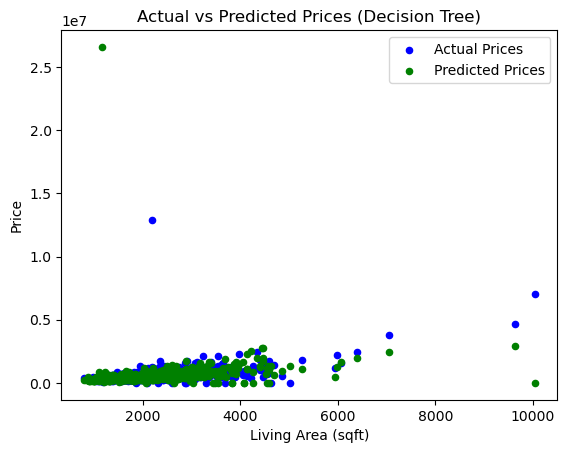

In [74]:
# Visualize predictions (using sqft_living for x-axis)
plot_df = pd.DataFrame({
        'sqft_living': X_test['sqft_living'],
        'actual_price': y_test,
        'predicted_price': y_pred
         })
ax = plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='green', label='Predicted Prices', ax=ax)
ax.set_xlabel('Living Area (sqft)')
ax.set_ylabel('Price')
ax.set_title('Actual vs Predicted Prices (Decision Tree)')
plt.savefig('decision_tree_predictions.png')
plt.show()